# AED - Análise Explorátoria de Dados

## Como lidar com dados ausentes

<div class="alert alert-danger">
     
**AVISO!**
 
Titulos clicáveis estão em **negrito** basta clicar na seta.
     
</div>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
wine = pd.read_csv('winemag-data-130k-v2.csv')
wine = wine.drop("Unnamed: 0",axis=1)

In [28]:
wine.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


<details>
  <summary>
    <font size='3', color='white'>
      <b>Coletar informações de dados ausentes</b>
    </font>
  </summary>
 
- Para descobrirmos em quais colunas estão os dados ausentes usamos:
```python
            print(wine.isna().sum())
```
</details>

In [8]:
print(wine.isna().sum())

Unnamed: 0                   0
country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


<details>
  <summary>
    <font size='3', color='white'>
      <b>Lidar com dados ausentes</b>
    </font>
  </summary>
 
- Existem estratégias para lidar com dados ausentes como 
  * Excluir valores ausentes se o total for menor que 5%

```python
            threshold = len(wine) * 0.05
            print(threshold) #pegar uma porcentagem do tamanho do dataframe
```
```python
            cols_to_drop = wine.columns[wine.isna().sum() <= threshold]
            print(cols_to_drop) #achar as colunas faltantes para eliminar
```
```python
            wine.dropna(subset=cols_to_drop, inplace=True)      
            #removendo valores ausentes e inplace "True" atualiza o dataframe.
```
  * Inputar média, mediana, moda dependendo do contexto.
```python
            cols_with_missing_values = wine.columns[wine.isna().sum() > 0]
            print(cols_with_missing_values) #Filtra as colunas por valores ausentes
```
```python
            for col in cols_with_missing_values[:-1]:
              wine[col].fillna(wine[col].mode()[0]) 
              #vai indexar a moda da respectiva coluna
```
  * Inputar por subgrupos
```python
            points_dict = wine.groupby("country")["points"].median().to_dict()
            print(points_dict)
```
```python
            wine["points"] = wine["points"].fillna(wine["country"].map(points_dict))
            print(wine.isna().sum()) #preencher dados ausentes com a mediana
```


</details>

##### Primeiro Caso

In [39]:
threshold = len(wine) * 0.05
print(threshold)

6498.55


In [40]:
cols_to_drop = wine.columns[wine.isna().sum() <= threshold]
print(cols_to_drop)

Index(['country', 'description', 'points', 'province', 'title', 'variety',
       'winery'],
      dtype='object')


In [ ]:
wine.dropna(subset=cols_to_drop, inplace=True)
#Nesse caso iria sumir com todas as colunas

##### Segundo Caso

In [42]:
cols_with_missing_values = wine.columns[wine.isna().sum() > 0]
print(cols_with_missing_values)

Index(['designation', 'price', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle'],
      dtype='object')


In [54]:
for col in cols_with_missing_values[:-1]:
    wine[col]=wine[col].fillna(wine[col].mode()[0]) 

In [55]:
print(wine.isna().sum())

country                     63
description                  0
designation                  0
points                       0
price                        0
province                    63
region_1                     0
region_2                     0
taster_name                  0
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


In [56]:
wine.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,20.0,Sicily & Sardinia,Etna,Central Coast,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,Napa Valley,Central Coast,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",Reserve,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,Central Coast,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


##### Terceiro Caso

In [68]:
points_dict = wine.groupby("country")["points"].median().to_dict()
print(points_dict)

{'Argentina': 87.0, 'Armenia': 87.5, 'Australia': 89.0, 'Austria': 90.0, 'Bosnia and Herzegovina': 86.5, 'Brazil': 85.0, 'Bulgaria': 89.0, 'Canada': 90.0, 'Chile': 86.0, 'China': 89.0, 'Croatia': 88.0, 'Cyprus': 87.0, 'Czech Republic': 88.0, 'Egypt': 84.0, 'England': 91.0, 'France': 89.0, 'Georgia': 88.0, 'Germany': 90.0, 'Greece': 87.0, 'Hungary': 89.0, 'India': 90.0, 'Israel': 89.0, 'Italy': 88.0, 'Lebanon': 88.0, 'Luxembourg': 88.5, 'Macedonia': 87.0, 'Mexico': 85.0, 'Moldova': 88.0, 'Morocco': 88.5, 'New Zealand': 88.0, 'Peru': 84.0, 'Portugal': 88.0, 'Romania': 86.0, 'Serbia': 87.5, 'Slovakia': 87.0, 'Slovenia': 88.0, 'South Africa': 88.0, 'Spain': 87.0, 'Switzerland': 89.0, 'Turkey': 88.0, 'US': 88.0, 'Ukraine': 84.0, 'Uruguay': 87.0}


In [ ]:
wine["points"] = wine["points"].fillna(wine["country"].map(points_dict))
print(wine.isna().sum()) 

country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


## Conversão e ánalise de dados categóricos

In [ ]:
print(wine['country'].value_counts())
#contagem de dados

country
US                        54504
France                    22093
Italy                     19540
Spain                      6645
Portugal                   5691
Chile                      4472
Argentina                  3800
Austria                    3345
Australia                  2329
Germany                    2165
New Zealand                1419
South Africa               1401
Israel                      505
Greece                      466
Canada                      257
Hungary                     146
Bulgaria                    141
Romania                     120
Uruguay                     109
Turkey                       90
Slovenia                     87
Georgia                      86
England                      74
Croatia                      73
Mexico                       70
Moldova                      59
Brazil                       52
Lebanon                      35
Morocco                      28
Peru                         16
Ukraine                      14


<details>
  <summary>
    <font size='3', color='white'>
      <b>.nunique( )</b>
    </font>
  </summary>
 
- Para vermos dados exclusivos
```python
            wine['country'].nunique( ) 
```
</details>

In [70]:
print(wine['country'].nunique())

43


<details>
  <summary>
    <font size='3', color='white'>
      <b>Extrair valor das categorias</b>
    </font>
  </summary>
 
- O formato atual limita a capacidade de insights
```python
            pd.Series.str.contains( )
```
* Pesquisar uma coluna por uma string específica ou várias strings
```python
            wine["country"].str.contains("Portugal")
            #devolve valores booleanos
```
</details>

In [72]:
wine["country"].str.contains("Portugal|Italy")

0          True
1          True
2         False
3         False
4         False
          ...  
129966    False
129967    False
129968    False
129969    False
129970    False
Name: country, Length: 129971, dtype: object

<details>
  <summary>
    <font size='3', color='white'>
      <b>Encontrar várias frases em strings</b>
    </font>
  </summary>
 
- Usando palavras de interesse para achar no dataframe oque busca.
```python
    country_categories = ["Brazil", "Spain", "US"]
    #Essa lista define os rótulos que serão atribuídos.

    pt_country = "Brazil|Portugal"
    es_country = "Spain|Chile|Argentina"
    en_country = "US|Canada|South Africa"
    #Aqui você cria expressões regulares, O | significa OU.

    conditions = [
        wine["country"].str.contains(pt_country, na=False),
        wine["country"].str.contains(es_country, na=False),
        wine["country"].str.contains(en_country, na=False)
    ]
    #Ele verifica, linha por linha, se o texto contém o padrão.

    wine["Country_Category"] = np.select(conditions, country_categories, default="Other")
    #Ele percorre cada linha e faz as condições
```
</details>

In [88]:
import numpy as np

country_categories = ["Português", "Espanhol", "Inglês"]

pt_country = "Brazil|Portugal"
es_country = "Spain|Chile|Argentina"
en_country = "US|Canada|South Africa"

conditions = [
    wine["country"].str.contains(pt_country, na=False),
    wine["country"].str.contains(es_country, na=False),
    wine["country"].str.contains(en_country, na=False)
]

wine["Country_Category"] = np.select(conditions, country_categories, default="Other")

In [89]:
print(wine[["country","Country_Category"]].head())

    country Country_Category
0     Italy            Other
1  Portugal        Português
2        US           Inglês
3        US           Inglês
4        US           Inglês


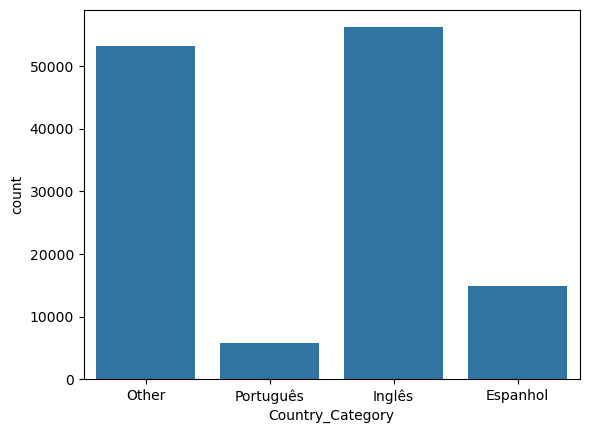

In [91]:
sns.countplot(data=wine,x="Country_Category")
plt.show()

## Como trabalhar com dados númericos

<details>
  <summary>
    <font size='3', color='white'>
      <b>Convertendo Strings para números</b>
    </font>
  </summary>
 
- Substituindo strings de coluna:
```python
            pd.Series.str.replace("oque vai ser removido", "oque vai substituir")

            pd.Series.astype(float) #transformando em float
```
</details>

<details>
  <summary>
    <font size='3', color='white'>
      <b>Adicionando estastísticas resumidas a um DataFrame</b>
    </font>
  </summary>
 
- Agrupa os dados por Points
  * Calcula o desvio padrão (std) dos preços (Price) em cada grupo
  * Cria a coluna price_std com esse valor repetido para cada linha do grupo
```python
          wine["price_std"] = wine.groupby("Points")["Price"].transform(lambda x: x.std())
          #Calcula a variação dos preços para cada pontuação
          #Adiciona isso como uma nova coluna no DataFrame.
```
</details>

In [97]:
wine["price_std"] = wine.groupby("points")["price"].transform(lambda x: x.std())
print(wine["price_std"])
wine.head()

0         18.518484
1         18.518484
2         18.518484
3         18.518484
4         18.518484
            ...    
129966    23.941968
129967    23.941968
129968    23.941968
129969    23.941968
129970    23.941968
Name: price_std, Length: 129971, dtype: float64


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,Country_Category,price_std
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Other,18.518484
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,Português,18.518484
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Inglês,18.518484
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Inglês,18.518484
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Inglês,18.518484


<details>
  <summary>
    <font size='3', color='white'>
      <b>2:.Adicionando estastísticas resumidas a um DataFrame</b>
    </font>
  </summary>
 
- Agrupa os dados pela coluna country
  * Pega os valores de Price dentro de cada país
  * Calcula a mediana (median) desses preços
  * Repete esse valor para todas as linhas daquele país
```python
       wine["median_by_country"] = wine.groupby("country")["Price"].transform(lambda x: x.median())
       #Calcula a mediana dos preços por país e adiciona isso como uma nova coluna.
```
</details>

In [99]:
wine["median_by_country"] = wine.groupby("country")["price"].transform(lambda x: x.median())
print(wine["median_by_country"])
wine.head()

0         28.0
1         16.0
2         30.0
3         30.0
4         30.0
          ... 
129966    26.0
129967    30.0
129968    25.0
129969    25.0
129970    25.0
Name: median_by_country, Length: 129971, dtype: float64


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,Country_Category,price_std,median_by_country
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Other,18.518484,28.0
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,Português,18.518484,16.0
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Inglês,18.518484,30.0
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Inglês,18.518484,30.0
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Inglês,18.518484,30.0


## Tratamento de valores discrepantes

<details>
  <summary>
    <font size='3', color='white'>
      <b>O que é uma discrepância</b>
    </font>
  </summary>
 
- Quando os dados estão bem diferentes um do outro
  * preço médio dos vinhos US$ 35.00
  * preço atípico do vinho US$ 4.000
```python
       wine["price"].describe()
       #pode ser usado para analisar a discrepância
```
</details>

In [101]:
print(wine["price"].describe())

count    120975.000000
mean         35.363389
std          41.022218
min           4.000000
25%          17.000000
50%          25.000000
75%          42.000000
max        3300.000000
Name: price, dtype: float64


<details>
  <summary>
    <font size='3', color='white'>
      <b>Identificar limites</b>
    </font>
  </summary>
 
```python
       setenta_cinco = wine["price"].quantile(0.75)
       vinte_cinco = wine["price"].quantile(0.25)

       price_iqr = setenta_cinco - vinte_cinco
       #Achando porcetagens e o valor iqr
```

```python
       upper = setenta_cinco + (1.5 * price_iqr)
       #limite superior
       lower = vinte_cinco + (1.5 * price_iqr)
       #limite inferior
```     
</details>

In [119]:
setenta_cinco = wine["price"].quantile(0.75)
vinte_cinco = wine["price"].quantile(0.25)

price_iqr = setenta_cinco - vinte_cinco

upper = setenta_cinco + (1.5 * price_iqr)
lower = vinte_cinco - (1.5 * price_iqr)

print(upper, lower)

79.5 -20.5


<details>
  <summary>
    <font size='3', color='white'>
      <b>Buscando discrepâncias </b>
    </font>
  </summary>
 
- As discrepâncias podem não representar o dado real, assim
caso necessário elimando eles.
```python
       wine[(wine["price"] < lower) | (wine["price"] > upper)] \
        [["points","country","price"]]
        #usado para buscar discrepâncias
```
```python
       dentro_dos_limites = wine[(wine["price"] < lower) | (wine["price"] > upper)] 
        #elimina discrepâncias
```
</details>

In [120]:
wine[(wine["price"] < lower) | (wine["price"] > upper)] \
        [["points","country","price"]]

,points,country,price
60,86,US,100.0
111,87,US,85.0
118,87,Italy,80.0
119,92,France,80.0
139,90,France,112.0
...,...,...,...
129886,91,Argentina,88.0
129887,91,Argentina,88.0
129891,91,US,100.0
129919,91,US,105.0


In [131]:
dentro_dos_limites = wine[(wine["price"] >= lower) & (wine["price"] <= upper)]

print(dentro_dos_limites["price"].describe())

count    113734.000000
mean         29.113695
std          16.173909
min           4.000000
25%          16.000000
50%          25.000000
75%          39.000000
max          79.000000
Name: price, dtype: float64


## Comparando Gráficos

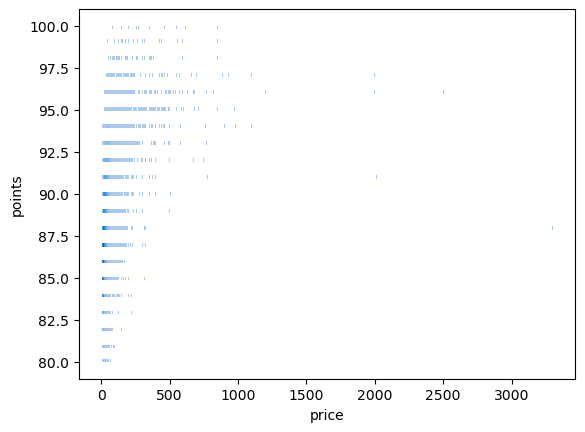

In [122]:
sns.histplot(data=wine,x="price",y="points")
plt.show()

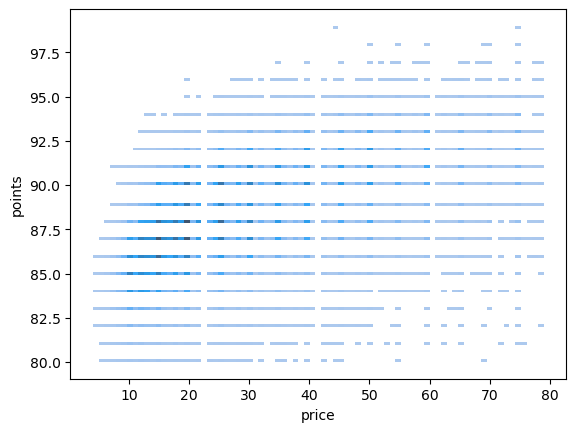

In [132]:
sns.histplot(data=dentro_dos_limites, x="price",y="points")
plt.show()